# Visualization API Demonstration

This notebook demonstrates the composable map API in `commute_analysis.visualization` with both Matplotlib and Folium backends.

In [82]:
import importlib
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, PowerNorm
import pandas as pd
import numpy as np
from pathlib import Path
from shapely.geometry import LineString, Point, Polygon

from commute_analysis.synthetic_population import (
    calculate_sampling_probability_grid,
    sample_population_weighted_locations,
)
import commute_analysis.visualization as viz
import commute_analysis.routing as routing
import commute_analysis.geometry as geometry

BASE_DIR = "/home/msing/proj/jjdatascience/deutschlandticket-commute-analysis"

# Force reload so notebook picks up local source changes during iterative development
importlib.reload(viz)

plot_commute_map = viz.plot_commute_map
plot_routes = viz.plot_routes
plot_sampling_probability_map = viz.plot_sampling_probability_map
plot_synthetic_employees = viz.plot_synthetic_employees

## 1. Build a small probability grid

For a lightweight demo, this notebook generates a synthetic polygon grid and computes sampling probabilities.

In [15]:
grid_cells = []
pop_values = []
x0, y0 = 10.00, 53.50
step = 0.005
for i in range(6):
    for j in range(5):
        x = x0 + i * step
        y = y0 + j * step
        grid_cells.append(Polygon([(x, y), (x + step, y), (x + step, y + step), (x, y + step)]))
        pop_values.append((i + 1) * (j + 2) * 10)

population_grid = gpd.GeoDataFrame({"population": pop_values}, geometry=grid_cells, crs="EPSG:4326")

target_area = gpd.GeoDataFrame(
    {"name": ["target"]},
    geometry=[Polygon([(9.995, 53.495), (10.04, 53.495), (10.04, 53.53), (9.995, 53.53)])],
    crs="EPSG:4326",
)

probability_grid = calculate_sampling_probability_grid(
    population_grid=population_grid,
    population_column="population",
    target_area=target_area,
    filter_mode="uniform",
)

probability_grid["cell_area_km2"] = probability_grid.to_crs("EPSG:3857").area / 1_000_000
probability_grid["probability_density_km2"] = probability_grid["sampling_probability"] / probability_grid["cell_area_km2"]

probability_grid.head()

,population,geometry,base_population,distance,distance_weight,sampling_weight,sampling_probability,cell_area_km2,probability_density_km2
0,20,"POLYGON ((10 53.505, 10.005 53.505, 10.005 53....",20.0,NaN,1.0,20.0,0.004762,0.520859,0.009142
5,40,"POLYGON ((10.005 53.505, 10.01 53.505, 10.01 5...",40.0,NaN,1.0,40.0,0.009524,0.520859,0.018285
10,60,"POLYGON ((10.01 53.505, 10.015 53.505, 10.015 ...",60.0,NaN,1.0,60.0,0.014286,0.520859,0.027427
1,30,"POLYGON ((10 53.51, 10.005 53.51, 10.005 53.50...",30.0,NaN,1.0,30.0,0.007143,0.520921,0.013712
6,60,"POLYGON ((10.005 53.51, 10.01 53.51, 10.01 53....",60.0,NaN,1.0,60.0,0.014286,0.520921,0.027424


In [55]:
# ------------------------------------------------------------
# 1. Define target area
# ------------------------------------------------------------

RADIUS_KM = 50
WORKPLACE = (53.686439, 10.046120)

target_area = geometry.create_target_area(WORKPLACE[0], WORKPLACE[1], RADIUS_KM)

# ------------------------------------------------------------
# 4. Calculate density in a metre-based CRS
# ------------------------------------------------------------

# EPSG:3035 is particularly suitable for European area calculations.
probability_grid = probability_grid.to_crs("EPSG:3035").copy()

probability_grid["cell_area_km2"] = (
    1 / 1_000_000
)

# probability_grid["probability_density_km2"] = (
#     probability_grid["sampling_probability"]
#     / probability_grid["cell_area_km2"]
# )

# # Remove invalid values
# probability_grid["probability_density_km2"] = (
#     probability_grid["probability_density_km2"]
#     .replace([np.inf, -np.inf], np.nan)
# )

# probability_grid = probability_grid.dropna(
#     subset=["probability_density_km2"]
# )

## 2. Generate synthetic employees and define workplace

In [16]:
employees = sample_population_weighted_locations(
    population_grid=population_grid,
    population_column="population",
    n=30,
    target_area=target_area,
    seed=7,
    filter_mode="uniform",
)
workplace = Point(10.03, 53.525)
employees.head()

,employee_id,source_population,source_probability,distance_weight,geometry
0,EMP-00001,180.0,0.042857,1.0,POINT (10.01248 53.52124)
1,EMP-00002,300.0,0.071429,1.0,POINT (10.02006 53.52096)
2,EMP-00003,300.0,0.071429,1.0,POINT (10.02846 53.516)
3,EMP-00004,120.0,0.028571,1.0,POINT (10.01685 53.50502)
4,EMP-00005,180.0,0.042857,1.0,POINT (10.02915 53.50577)


### Actual mock employee data generation

In [77]:
NUM_EMPLOYEES = 10
employees = sample_population_weighted_locations(population_gdf, "Einwohner", NUM_EMPLOYEES, target_area=target_area, filter_mode="gaussian", gaussian_scale=GAUSSIAN_SCALE)

## 3. Create representative route data (mocked)

Route calculation can be expensive and depends on local OSM/GTFS data. For visualization tests we use mocked route segment GeoDataFrames with realistic columns.

In [38]:
def make_route(start_pt, end_pt, route_id, option=0):
    mid1 = Point((start_pt.x + end_pt.x) / 2 - 0.004, (start_pt.y + end_pt.y) / 2 + 0.002)
    mid2 = Point((start_pt.x + end_pt.x) / 2 + 0.003, (start_pt.y + end_pt.y) / 2 + 0.001)
    rows = [
        {
            "option": option,
            "segment": 1,
            "leg_index": 0,
            "transport_mode": "walk",
            "leg_mode": "walk",
            "departure_time": pd.Timestamp("2026-07-21 07:30"),
            "arrival_time": pd.Timestamp("2026-07-21 07:35"),
            "travel_time": pd.Timedelta(minutes=5),
            "distance": 600.0,
            "from_id": f"EMP-{route_id:03d}",
            "to_id": "WORK",
            "geometry": LineString([start_pt, mid1]),
        },
        {
            "option": option,
            "segment": 2,
            "leg_index": 1,
            "transport_mode": "bus",
            "leg_mode": "bus",
            "departure_time": pd.Timestamp("2026-07-21 07:37"),
            "arrival_time": pd.Timestamp("2026-07-21 07:50"),
            "travel_time": pd.Timedelta(minutes=13),
            "distance": 2200.0,
            "from_id": f"EMP-{route_id:03d}",
            "to_id": "WORK",
            "geometry": LineString([mid1, mid2]),
        },
        {
            "option": option,
            "segment": 3,
            "leg_index": 2,
            "transport_mode": "walk",
            "leg_mode": "walk",
            "departure_time": pd.Timestamp("2026-07-21 07:51"),
            "arrival_time": pd.Timestamp("2026-07-21 07:55"),
            "travel_time": pd.Timedelta(minutes=4),
            "distance": 450.0,
            "from_id": f"EMP-{route_id:03d}",
            "to_id": "WORK",
            "geometry": LineString([mid2, end_pt]),
        },
    ]
    return gpd.GeoDataFrame(rows, crs="EPSG:4326")

employee_points = employees.to_crs("EPSG:4326")
route_1 = make_route(employee_points.geometry.iloc[0], workplace, route_id=1, option=0)
route_2 = make_route(employee_points.geometry.iloc[1], workplace, route_id=2, option=0)
route_3 = make_route(employee_points.geometry.iloc[2], workplace, route_id=3, option=0)

route_with_alternatives = pd.concat([
    make_route(employee_points.geometry.iloc[0], workplace, route_id=99, option=0),
    make_route(employee_points.geometry.iloc[0], workplace, route_id=99, option=1),
], ignore_index=True)
route_with_alternatives = gpd.GeoDataFrame(route_with_alternatives, geometry="geometry", crs="EPSG:4326")

route_1.head()

## 4. Matplotlib examples

In [ ]:
# Density plotting now auto-adjusts normalization and transparency defaults in visualization.py.
plot_sampling_probability_map(
    probability_grid,
    target_area=target_area,
    workplace=WORKPLACE,
    backend="matplotlib",
    figsize=(10, 12),
    add_basemap=True,
)

<Axes: >

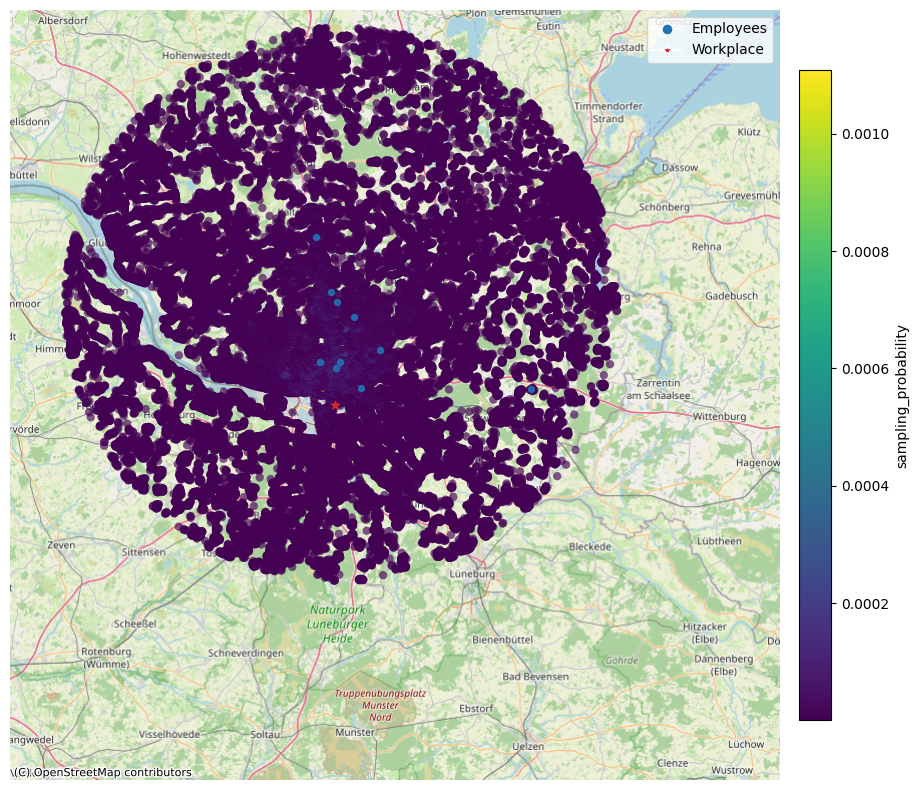

In [ ]:
plot_synthetic_employees(
    employees,
    target_area=None,
    workplace=workplace,
    backend="matplotlib",
    add_basemap=True,
    show_probability_grid=False,
)

<Axes: >

<Axes: >

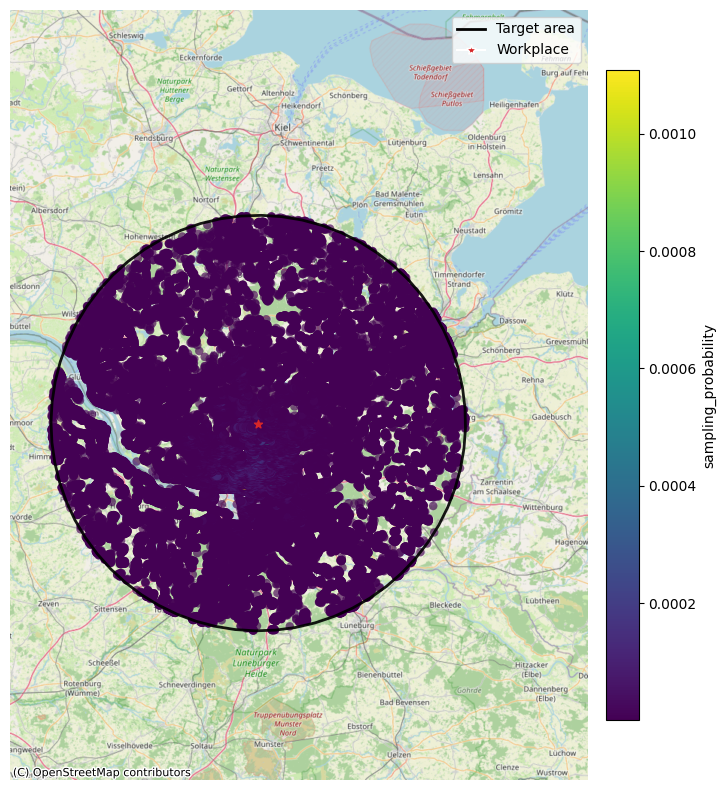

In [46]:
plot_routes(
    route_1,
    origins=employee_points.iloc[[0]],
    destinations=workplace,
    backend="matplotlib",
    add_basemap=False,
    show_probability_grid=False,
    show_route_segment_labels=True,
    route_color_strategy="segment",
)

<Axes: title={'center': 'Fully combined static map'}>

<Axes: title={'center': 'Fully combined static map'}>

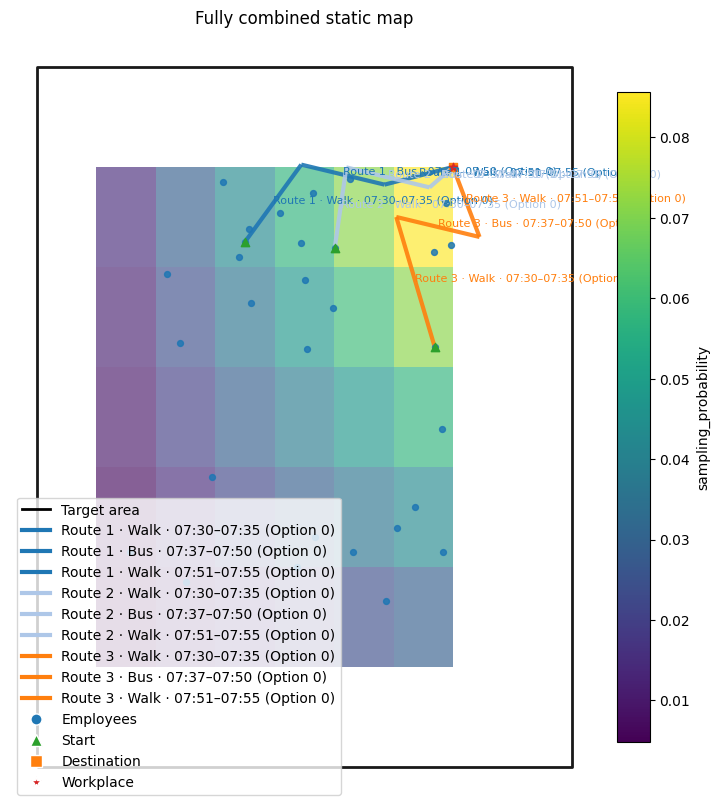

In [21]:
plot_commute_map(
    probability_grid=probability_grid,
    employees=employees,
    target_area=target_area,
    workplace=workplace,
    routes=[route_1, route_2, route_3],
    route_origins=[employee_points.iloc[[0]], employee_points.iloc[[1]], employee_points.iloc[[2]]],
    route_destinations=workplace,
    backend="matplotlib",
    add_basemap=False,
    route_color_strategy="route",
    title="Fully combined static map",
)

<Axes: title={'center': 'Visibility controls'}>

<Axes: title={'center': 'Visibility controls'}>

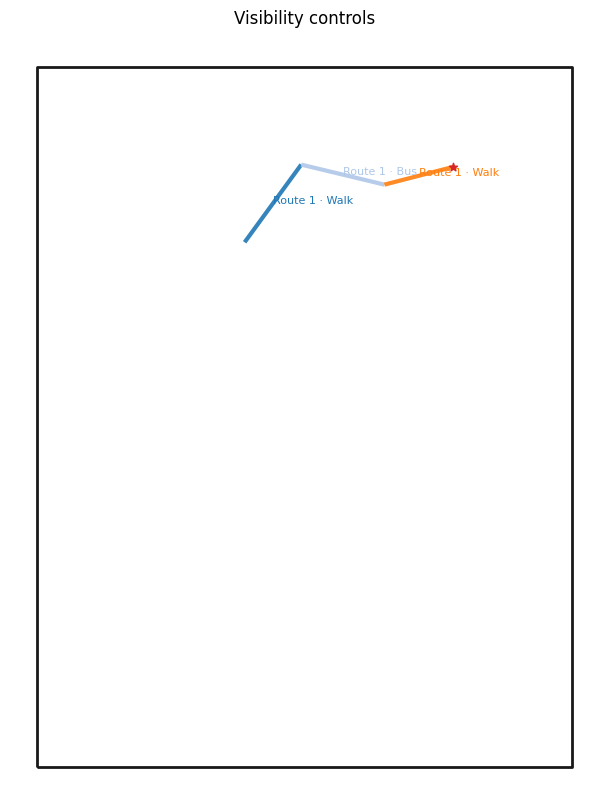

In [22]:
# Visibility controls
plot_commute_map(
    probability_grid=probability_grid,
    employees=employees,
    target_area=target_area,
    workplace=workplace,
    routes=route_1,
    route_origins=employee_points.iloc[[0]],
    route_destinations=workplace,
    backend="matplotlib",
    add_basemap=False,
    show_probability_grid=False,
    show_employees=False,
    show_route_origins=False,
    show_route_destinations=False,
    show_route_times=False,
    show_legend=False,
    title="Visibility controls",
)

<Axes: title={'center': 'Layered on existing axis'}>

<Axes: title={'center': 'Layered on existing axis'}>

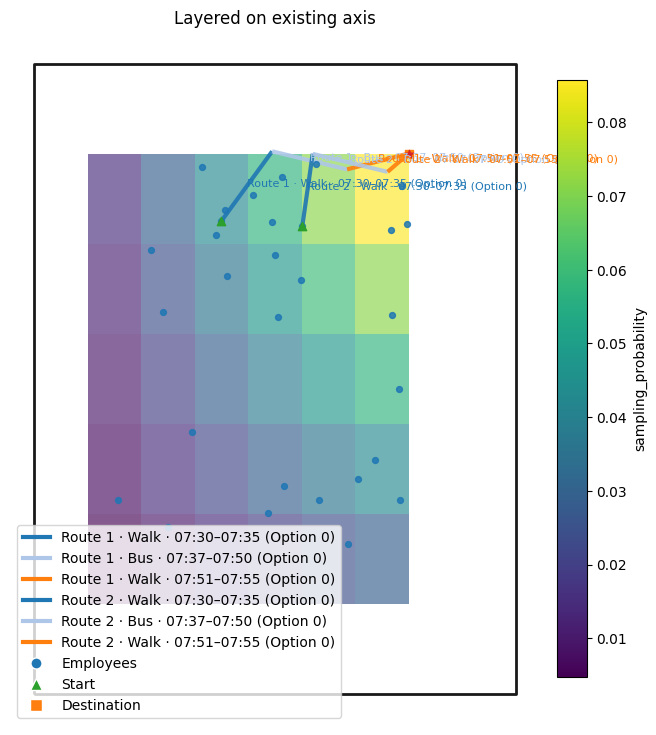

In [23]:
# Reuse an existing matplotlib axis for layered composition
fig, ax = plt.subplots(figsize=(11, 9))
plot_commute_map(
    probability_grid=probability_grid,
    target_area=target_area,
    workplace=workplace,
    backend="matplotlib",
    add_basemap=False,
    show_legend=False,
    ax=ax,
)
plot_commute_map(
    employees=employees,
    routes=[route_1, route_2],
    route_origins=[employee_points.iloc[[0]], employee_points.iloc[[1]]],
    route_destinations=workplace,
    backend="matplotlib",
    add_basemap=False,
    show_probability_grid=False,
    ax=ax,
    title="Layered on existing axis",
)
ax

## 5. Folium examples

Folium is optional. If not installed, this section prints an explanatory message.

In [28]:
try:
    import folium

    fmap = plot_commute_map(
        probability_grid=probability_grid,
        target_area=target_area,
        backend="folium",
    )

    fmap = plot_commute_map(
        employees=employees,
        routes=[route_1, route_2],
        route_origins=[employee_points.iloc[[0]], employee_points.iloc[[1]]],
        route_destinations=workplace,
        workplace=workplace,
        backend="folium",
        folium_map=fmap,
        show_probability_grid=False,
        cluster_employees=True,
    )

    fmap
    fmap.save(Path(BASE_DIR) / "outputs" / "test_vis_map.html")
except ImportError:
    print("folium is not installed. Install with: pip install folium")

## 6. Route option selection behavior

Route 1 contains multiple itinerary options. Specify route_options to select one option per route.


<Axes: title={'center': 'Selected route option 1'}>

Route 1 contains multiple itinerary options. Specify route_options to select one option per route.


<Axes: title={'center': 'Selected route option 1'}>

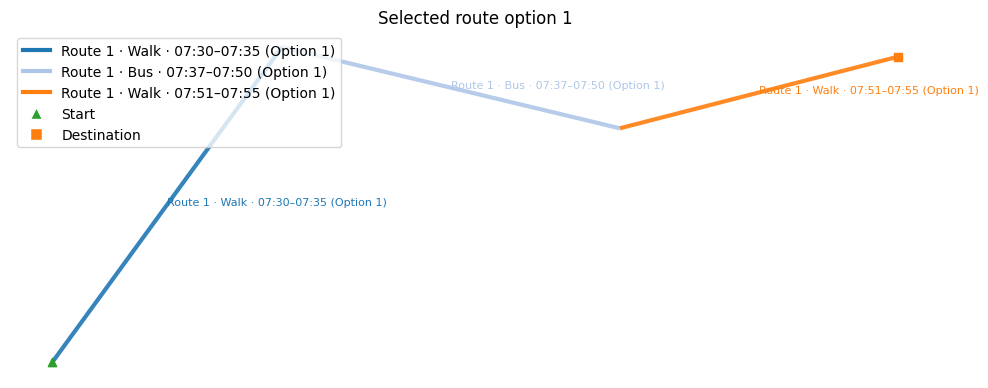

In [29]:
# This call raises a ValueError because two options exist and no route_options is given.
try:
    plot_commute_map(routes=route_with_alternatives, show_probability_grid=False, add_basemap=False)
except ValueError as exc:
    print(exc)

# Explicit option selection works
plot_commute_map(
    routes=route_with_alternatives,
    route_options=1,
    route_origins=employee_points.iloc[[0]],
    route_destinations=workplace,
    show_probability_grid=False,
    add_basemap=False,
    title="Selected route option 1",
)

## 7. Expected input schemas and return values

- `probability_grid`: GeoDataFrame with CRS and a numeric probability column (default `sampling_probability`).
- `employees`: point GeoDataFrame (for example with `employee_id`).
- `routes`: one or more segment GeoDataFrames with `geometry`; optional route metadata like `option`, `segment`, `leg_index`, `transport_mode`/`leg_mode`, `departure_time`, `arrival_time`, `travel_time`.
- `target_area`: polygon GeoDataFrame/GeoSeries.
- `workplace`, `route_origins`, `route_destinations`: point-like values (`Point`, tuple, `GeoSeries`, or `GeoDataFrame`).

Returns:
- Matplotlib backend: `matplotlib.axes.Axes`
- Folium backend: `folium.Map`